# MLBB Vision Pipeline — Local Screenshot Analysis (Offline)

Replaces Gemini Vision for scrim screenshot analysis. Two pipelines:

1. **Draft screenshot** → 10 ban icons (5 our / 5 enemy) → OpenCV template matching vs `public/heroes/*.webp`
2. **Scoreboard screenshot** → VICTORY/DEFEAT OCR + 10 player rows (hero via CLIP similarity — skin-robust, KDA via EasyOCR)

**Workflow:**
- All crop coordinates are **normalized (x, y, w, h)** against a 1920x1080 canvas (input is resized first).
- Drop real screenshots into `samples/` as `draft*.png|jpg` and `scoreboard*.png|jpg`, rerun the overlay cells, and tune `DRAFT_CFG` / `SCORE_CFG` until boxes line up.
- Synthetic validation cells at the bottom prove the matching algorithms end-to-end without real screenshots.


In [1]:
import os
os.environ.setdefault("USE_TF", "0")  # sentence_transformers breaks on Keras 3 without this

import io, re, json, random
from pathlib import Path

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

CANVAS_W, CANVAS_H = 1920, 1080


def find_root():
    p = Path.cwd()
    for cand in [p, *p.parents]:
        if (cand / "public" / "heroes").is_dir():
            return cand
    raise RuntimeError("public/heroes not found above cwd")


ROOT = find_root()
HEROES_DIR = ROOT / "public" / "heroes"
SAMPLES_DIR = ROOT / "scratch" / "mlbb-vision" / "samples"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)
print("templates:", len(list(HEROES_DIR.glob("*.webp"))))


ROOT: E:\hyperion-new
templates: 132


## Hero database — names + slug logic (ported from `features/scrim/data/mlbb-heroes.ts`)

In [2]:
MLBB_HEROES = sorted([
    "Aamon", "Akai", "Aldous", "Alpha", "Alucard", "Angela", "Atlas", "Aulus",
    "Aurora", "Badang", "Balmond", "Barats", "Baxia", "Beatrix", "Belerick",
    "Benedetta", "Brody", "Bruno", "Carmilla", "Cecilion", "Chang'e", "Chip",
    "Chou", "Cici", "Claude", "Clint", "Cyclops", "Diggie", "Dyrroth",
    "Esmeralda", "Estes", "Eudora", "Fanny", "Faramis", "Floryn", "Franco",
    "Freya", "Gatotkaca", "Gord", "Granger", "Grock", "Guinevere", "Gusion",
    "Hanabi", "Hanzo", "Harith", "Harley", "Hayabusa", "Helcurt", "Hilda",
    "Hylos", "Irithel", "Ixia", "Jawhead", "Johnson", "Joy", "Julian",
    "Kagura", "Karrie", "Khaleed", "Khufra", "Kimmy", "Lancelot", "Lapu-Lapu",
    "Layla", "Leomord", "Lesley", "Ling", "Lolita", "Lukas", "Lunox", "Lylia",
    "Mathilda", "Melissa", "Minsitthar", "Minotaur", "Miya", "Moskov",
    "Nana", "Natalia", "Natan", "Nolan", "Novaria", "Odette", "Paquito",
    "Pharsa", "Phoveus", "Popol and Kupa", "Rafaela", "Roger", "Ruby",
    "Saber", "Silvanna", "Sun", "Suyou", "Terizla", "Thamuz",
    "Tigreal", "Uranus", "Vale", "Valentina", "Valir", "Vexana", "Wanwan",
    "X.Borg", "Xavier", "Yi Sun-shin", "Yin", "Yu Zhong", "Yve", "Zhask",
    "Zhuxin", "Zilong",
    "Alice", "Bane", "Karina", "Argus", "Martis", "Kaja", "Selena", "Kadita",
    "Masha", "Luo Yi", "Edith", "Fredrinn", "Arlott", "Sora", "Marcel",
    "Gloo", "Kalea", "Zetian", "Obsidia",
])


def hero_to_slug(name: str) -> str:
    s = name.lower().replace("'", "").replace(".", "")
    s = re.sub(r"\s+", "-", s)
    return re.sub(r"[^a-z0-9-]", "", s)


missing = [h for h in MLBB_HEROES if not (HEROES_DIR / (hero_to_slug(h) + ".webp")).is_file()]
print(len(MLBB_HEROES), "heroes;", "missing templates:", missing or "none")


132 heroes; missing templates: none


## Template database — circular-masked 96px tiles

templates loaded: 132


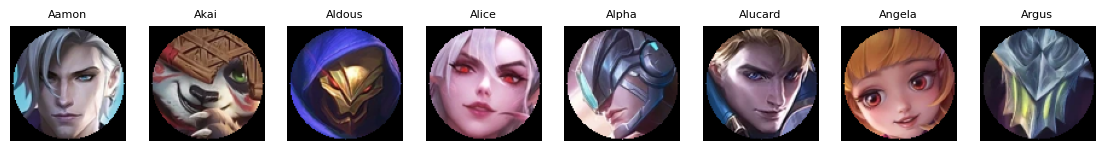

In [3]:
TILE = 96
MASK = np.zeros((TILE, TILE), np.uint8)
cv2.circle(MASK, (TILE // 2, TILE // 2), TILE // 2 - 2, 255, -1)


def to_bgr(pil_img):
    return cv2.cvtColor(np.array(pil_img.convert("RGB")), cv2.COLOR_RGB2BGR)


def prep_tile(bgr):
    """Resize to TILE and apply circular mask (ban/scoreboard icons are circular)."""
    a = cv2.resize(bgr, (TILE, TILE), interpolation=cv2.INTER_AREA)
    return cv2.bitwise_and(a, a, mask=MASK)


TEMPLATES = {}
for name in MLBB_HEROES:
    p = HEROES_DIR / (hero_to_slug(name) + ".webp")
    if p.is_file():
        TEMPLATES[name] = prep_tile(to_bgr(Image.open(p)))
NAMES = list(TEMPLATES.keys())
print("templates loaded:", len(TEMPLATES))

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for ax, name in zip(axes, NAMES[:8]):
    ax.imshow(cv2.cvtColor(TEMPLATES[name], cv2.COLOR_BGR2RGB)); ax.set_title(name, fontsize=8); ax.axis("off")
plt.show()


## Crop coordinate config (normalized, tune against real screenshots)

Boxes are `(x, y, w, h)` fractions of the 1920x1080 canvas. These defaults are estimates from
the standard MLBB UI — **calibrate with the overlay cells below once real samples are in `samples/`**.

In [4]:
DRAFT_CFG = {
    # 5 ban icon slots, our team top-left
    "our_bans":   [(0.118 + i * 0.0455, 0.030, 0.038, 0.067) for i in range(5)],
    # enemy top-right, mirrored, listed left-to-right on screen
    "enemy_bans": [(1.0 - (0.118 + (4 - i) * 0.0455) - 0.038, 0.030, 0.038, 0.067) for i in range(5)],
}

SCORE_CFG = {
    "banner": (0.330, 0.010, 0.340, 0.150),   # VICTORY / DEFEAT text area, top-center
    "rows": {
        "y0": 0.250,          # top of first player row
        "h": 0.122,           # row pitch
        "hero_w": 0.046,
        "hero_h": 0.082,
        "our_hero_x": 0.060,   # hero portrait x, left column
        "enemy_hero_x": 0.530, # hero portrait x, right column
        "our_kda": (0.215, 0.115),    # (x, w) of KDA text area; y/h follow the row
        "enemy_kda": (0.685, 0.115),
    },
}


def crop_norm(img, box):
    x, y, w, h = box
    H, W = img.shape[:2]
    x0, y0 = int(x * W), int(y * H)
    return img[y0:y0 + int(h * H), x0:x0 + int(w * W)]


def load_canvas(src):
    """Accepts a path or raw bytes; returns BGR canvas resized to 1920x1080."""
    pil = Image.open(src if isinstance(src, (str, Path)) else io.BytesIO(src))
    return cv2.resize(to_bgr(pil), (CANVAS_W, CANVAS_H), interpolation=cv2.INTER_AREA)


def scoreboard_boxes():
    """Yield (side, row_index, hero_box, kda_box) for all 10 player rows."""
    r = SCORE_CFG["rows"]
    for i in range(5):
        y = r["y0"] + i * r["h"]
        for side in ("our", "enemy"):
            hero_box = (r[f"{side}_hero_x"], y, r["hero_w"], r["hero_h"])
            kx, kw = r[f"{side}_kda"]
            kda_box = (kx, y, kw, r["hero_h"])
            yield side, i, hero_box, kda_box


## Calibration overlay — run after dropping real screenshots into `samples/`

Green = ban/hero boxes, cyan = KDA boxes, yellow = result banner. Edit the configs above and rerun until aligned.

In [5]:
def draw_boxes(canvas, boxes, color, label=None):
    out = canvas
    for b in boxes:
        x, y, w, h = b
        p1 = (int(x * CANVAS_W), int(y * CANVAS_H))
        p2 = (int((x + w) * CANVAS_W), int((y + h) * CANVAS_H))
        cv2.rectangle(out, p1, p2, color, 3)
    return out


def show(img, title="", figsize=(16, 9)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title(title); plt.axis("off"); plt.show()


draft_samples = sorted([*SAMPLES_DIR.glob("draft*.png"), *SAMPLES_DIR.glob("draft*.jpg"), *SAMPLES_DIR.glob("draft*.jpeg"), *SAMPLES_DIR.glob("draft*.webp")])
score_samples = sorted([*SAMPLES_DIR.glob("scoreboard*.png"), *SAMPLES_DIR.glob("scoreboard*.jpg"), *SAMPLES_DIR.glob("scoreboard*.jpeg"), *SAMPLES_DIR.glob("scoreboard*.webp")])
print("draft samples:", [p.name for p in draft_samples] or "NONE — drop files into samples/")
print("scoreboard samples:", [p.name for p in score_samples] or "NONE — drop files into samples/")

if draft_samples:
    c = load_canvas(draft_samples[0]).copy()
    draw_boxes(c, DRAFT_CFG["our_bans"] + DRAFT_CFG["enemy_bans"], (0, 255, 0))
    show(c, "draft: ban boxes")

if score_samples:
    c = load_canvas(score_samples[0]).copy()
    draw_boxes(c, [SCORE_CFG["banner"]], (0, 255, 255))
    for side, i, hb, kb in scoreboard_boxes():
        draw_boxes(c, [hb], (0, 255, 0))
        draw_boxes(c, [kb], (255, 255, 0))
    show(c, "scoreboard: hero + KDA + banner boxes")


draft samples: NONE — drop files into samples/
scoreboard samples: NONE — drop files into samples/


## Matcher A — OpenCV template matching (draft bans: always default avatar, no skin)

In [6]:
def hsv_hist(tile):
    h = cv2.calcHist([cv2.cvtColor(tile, cv2.COLOR_BGR2HSV)], [0, 1], MASK, [24, 16], [0, 180, 0, 256])
    cv2.normalize(h, h)
    return h


TEMPLATE_HISTS = {name: hsv_hist(t) for name, t in TEMPLATES.items()}


def match_hero_template(crop_bgr, min_score=0.35):
    """Equal-size TM_CCOEFF_NORMED (=> correlation coefficient) + HSV hist tiebreak.
    Returns (hero_name | "", combined_score)."""
    if crop_bgr is None or crop_bgr.size == 0:
        return "", 0.0
    p = prep_tile(crop_bgr)
    ph = hsv_hist(p)
    best_name, best_score = "", -1.0
    for name, t in TEMPLATES.items():
        tm = float(cv2.matchTemplate(p, t, cv2.TM_CCOEFF_NORMED)[0][0])
        hs = float(cv2.compareHist(ph, TEMPLATE_HISTS[name], cv2.HISTCMP_CORREL))
        s = 0.7 * tm + 0.3 * hs
        if s > best_score:
            best_name, best_score = name, s
    return (best_name if best_score >= min_score else ""), best_score


## Matcher B — CLIP embedding similarity (scoreboard heroes: skin-robust)

In [7]:
from sentence_transformers import SentenceTransformer

clip = SentenceTransformer("clip-ViT-B-32")


def to_pil(bgr):
    return Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))


TEMPLATE_EMB = clip.encode([to_pil(TEMPLATES[n]) for n in NAMES], normalize_embeddings=True, batch_size=32, show_progress_bar=False)
print("embedding matrix:", TEMPLATE_EMB.shape)


def match_hero_clip(crop_bgr, min_score=0.55, topk=1):
    if crop_bgr is None or crop_bgr.size == 0:
        return ("", 0.0) if topk == 1 else []
    e = clip.encode([to_pil(prep_tile(crop_bgr))], normalize_embeddings=True, show_progress_bar=False)[0]
    sims = TEMPLATE_EMB @ e
    order = np.argsort(-sims)
    if topk > 1:
        return [(NAMES[i], float(sims[i])) for i in order[:topk]]
    i = int(order[0])
    return (NAMES[i] if sims[i] >= min_score else ""), float(sims[i])


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


embedding matrix: (132, 512)


## OCR — EasyOCR for VICTORY/DEFEAT + KDA text

In [8]:
import easyocr

reader = easyocr.Reader(["en"], gpu=False, verbose=False)


def ocr_text(crop, allowlist=None):
    if crop is None or crop.size == 0:
        return ""
    return " ".join(reader.readtext(crop, detail=0, allowlist=allowlist))


def detect_result(canvas):
    banner = crop_norm(canvas, SCORE_CFG["banner"])
    txt = ocr_text(banner).upper()
    if "VICTOR" in txt:
        return "win"
    if "DEFEAT" in txt or "DEFFEAT" in txt:
        return "loss"
    # color fallback: VICTORY banner is gold, DEFEAT is blue/grey
    hsv = cv2.cvtColor(banner, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    gold_ratio = float(((h > 15) & (h < 40) & (s > 80) & (v > 120)).mean())
    return "win" if gold_ratio > 0.05 else "loss"


KDA_RE = re.compile(r"(\d{1,2})\s*/\s*(\d{1,2})\s*/\s*(\d{1,2})")


def read_kda(crop):
    """2x upscale -> digits-only OCR -> parse k/d/a. Returns (0,0,0) when unreadable."""
    if crop is None or crop.size == 0:
        return 0, 0, 0
    big = cv2.resize(crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    txt = ocr_text(big, allowlist="0123456789/ ")
    m = KDA_RE.search(txt)
    if not m:
        return 0, 0, 0
    return tuple(int(g) for g in m.groups())


## End-to-end pipelines

In [9]:
def analyze_draft(canvas):
    return {
        "bans": [match_hero_template(crop_norm(canvas, b))[0] for b in DRAFT_CFG["our_bans"]],
        "enemyBans": [match_hero_template(crop_norm(canvas, b))[0] for b in DRAFT_CFG["enemy_bans"]],
    }


def analyze_scoreboard(canvas):
    players = [None] * 5
    enemy = [None] * 5
    for side, i, hero_box, kda_box in scoreboard_boxes():
        hero, _ = match_hero_clip(crop_norm(canvas, hero_box))
        k, d, a = read_kda(crop_norm(canvas, kda_box))
        entry = {"hero": hero, "kills": k, "deaths": d, "assists": a}
        (players if side == "our" else enemy)[i] = entry
    return {"result": detect_result(canvas), "players": players, "enemyPlayers": enemy}


## Inspect real samples (if present) — crops + predictions

Use this after calibration: every ban/hero crop is shown with its predicted hero so misalignments and mismatches are obvious.

In [10]:
def inspect_draft(path):
    canvas = load_canvas(path)
    boxes = DRAFT_CFG["our_bans"] + DRAFT_CFG["enemy_bans"]
    fig, axes = plt.subplots(1, 10, figsize=(18, 2.4))
    for ax, b in zip(axes, boxes):
        crop = crop_norm(canvas, b)
        name, score = match_hero_template(crop)
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{name or '?'}\n{score:.2f}", fontsize=7); ax.axis("off")
    plt.suptitle(Path(path).name); plt.show()
    print(json.dumps(analyze_draft(canvas), indent=2))


def inspect_scoreboard(path):
    canvas = load_canvas(path)
    fig, axes = plt.subplots(2, 5, figsize=(16, 5))
    for side, i, hero_box, kda_box in scoreboard_boxes():
        crop = crop_norm(canvas, hero_box)
        name, score = match_hero_clip(crop)
        ax = axes[0 if side == "our" else 1][i]
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{name or '?'} {score:.2f}", fontsize=7); ax.axis("off")
    plt.suptitle(Path(path).name + "  (row 0 = our, row 1 = enemy)"); plt.show()
    print(json.dumps(analyze_scoreboard(canvas), indent=2))


for p in draft_samples:
    inspect_draft(p)
for p in score_samples:
    inspect_scoreboard(p)


## Synthetic validation — proves matching + OCR end-to-end without real screenshots

Builds fake 1920x1080 draft/scoreboard images by pasting hero templates at the configured
coordinates (with JPEG-60 compression + ±2px jitter to simulate capture loss), then runs the full pipeline.

In [11]:
random.seed(42)


def degrade(canvas, jpeg_q=60):
    ok, enc = cv2.imencode(".jpg", canvas, [cv2.IMWRITE_JPEG_QUALITY, jpeg_q])
    return cv2.imdecode(enc, cv2.IMREAD_COLOR)


def paste(canvas, tile_bgr, box, jitter=2):
    x, y, w, h = box
    x0 = int(x * CANVAS_W) + random.randint(-jitter, jitter)
    y0 = int(y * CANVAS_H) + random.randint(-jitter, jitter)
    ww, hh = int(w * CANVAS_W), int(h * CANVAS_H)
    canvas[y0:y0 + hh, x0:x0 + ww] = cv2.resize(tile_bgr, (ww, hh))


def synth_draft():
    canvas = np.full((CANVAS_H, CANVAS_W, 3), 24, np.uint8)
    chosen = random.sample(NAMES, 10)
    for name, box in zip(chosen, DRAFT_CFG["our_bans"] + DRAFT_CFG["enemy_bans"]):
        paste(canvas, TEMPLATES[name], box)
    return degrade(canvas), chosen


def synth_scoreboard():
    canvas = np.full((CANVAS_H, CANVAS_W, 3), 24, np.uint8)
    win = random.random() < 0.5
    bx, by, bw, bh = SCORE_CFG["banner"]
    org = (int((bx + 0.08) * CANVAS_W), int((by + bh * 0.7) * CANVAS_H))
    cv2.putText(canvas, "VICTORY" if win else "DEFEAT", org, cv2.FONT_HERSHEY_TRIPLEX, 2.6,
                (0, 200, 255) if win else (200, 160, 120), 5)
    chosen = random.sample(NAMES, 10)
    truth = {"result": "win" if win else "loss", "players": [], "enemyPlayers": []}
    idx = 0
    for side, i, hero_box, kda_box in scoreboard_boxes():
        name = chosen[idx]; idx += 1
        paste(canvas, TEMPLATES[name], hero_box)
        k, d, a = random.randint(0, 19), random.randint(0, 12), random.randint(0, 25)
        kx, ky, kw, kh = kda_box
        org = (int((kx + 0.005) * CANVAS_W), int((ky + kh * 0.65) * CANVAS_H))
        cv2.putText(canvas, f"{k}/{d}/{a}", org, cv2.FONT_HERSHEY_SIMPLEX, 1.0, (235, 235, 235), 2)
        truth["players" if side == "our" else "enemyPlayers"].append(
            {"hero": name, "kills": k, "deaths": d, "assists": a})
    return degrade(canvas), truth


DRAFT ban accuracy (template matching): 100/100 = 100.0%


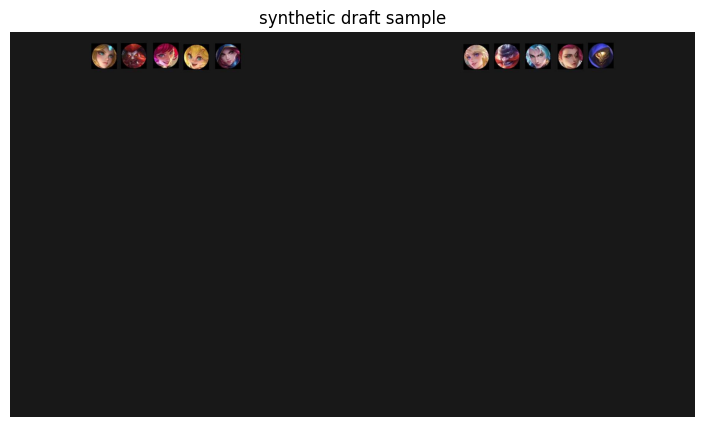

truth: ['Edith', 'Minotaur', 'Beatrix', 'Joy', 'Natalia', 'Kimmy', 'Franco', 'Suyou', 'Lesley', 'Aldous']


pred : {'bans': ['Edith', 'Minotaur', 'Beatrix', 'Joy', 'Natalia'], 'enemyBans': ['Kimmy', 'Franco', 'Suyou', 'Lesley', 'Aldous']}


In [12]:
# Draft eval: N synthetic drafts -> ban recognition accuracy
N = 10
hits = total = 0
for _ in range(N):
    canvas, chosen = synth_draft()
    pred = analyze_draft(canvas)
    got = pred["bans"] + pred["enemyBans"]
    hits += sum(1 for a, b in zip(got, chosen) if a == b)
    total += 10
print(f"DRAFT ban accuracy (template matching): {hits}/{total} = {hits/total:.1%}")
assert hits / total >= 0.95, "draft template matching below 95% on synthetic data"

canvas, chosen = synth_draft()
show(canvas, "synthetic draft sample", figsize=(14, 5))
print("truth:", chosen)
print("pred :", analyze_draft(canvas))


C:\Users\jokil\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


SCOREBOARD hero accuracy (CLIP): 39/40 = 97.5%
SCOREBOARD KDA accuracy (EasyOCR): 40/40 = 100.0%
SCOREBOARD result accuracy: 4/4


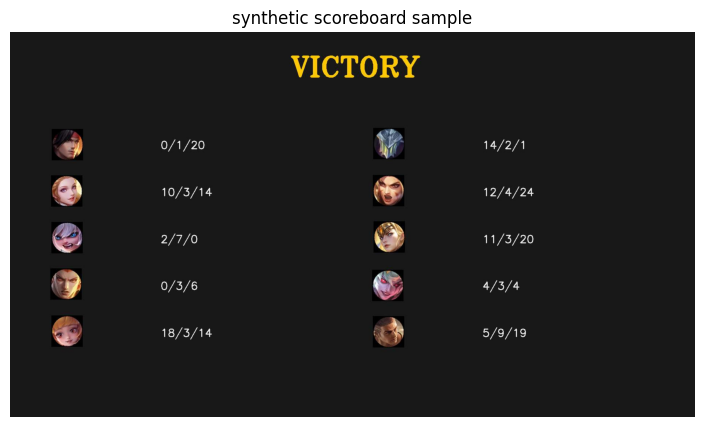

pred: {
  "result": "win",
  "players": [
    {
      "hero": "Leomord",
      "kills": 0,
      "deaths": 1,
      "assists": 20
    },
    {
      "hero": "Odette",
      "kills": 10,
      "deaths": 3,
      "assists": 14
    },
    {
      "hero": "Popol and Kupa",
      "kills": 2,
      "deaths": 7,
      "assists": 0
    },
    {
      "hero": "Valir",
      "kills": 0,
      "deaths": 3,
      "assists": 6
    },
    {
      "hero": "Angela",
      "kills": 18,
      "deaths": 3,
      "assists": 14
    }
  ],
  "enemyPlayers": [
    {
      "hero": "Argus",
      "kills": 14,
      "deaths": 2,
      "assists": 1
    },
    {
      "hero": "Masha",
      "kills": 12,
      "deaths": 4,
      "assists": 24
    },
    {
      "hero": "Freya",
      "kills": 11,
      "deaths": 3,
      "assists": 20
    },
    {
      "hero": "Dyrroth",
      "kills": 4,
      "deaths": 3,
      "assists": 4
    },
    {
      "hero": "Paquito",
      "kills": 5,
      "deaths": 9,
      "assist

In [13]:
# Scoreboard eval: hero (CLIP), KDA (OCR), result (OCR/color)
M = 4
hero_hits = kda_hits = res_hits = 0
for _ in range(M):
    canvas, truth = synth_scoreboard()
    pred = analyze_scoreboard(canvas)
    res_hits += int(pred["result"] == truth["result"])
    for key in ("players", "enemyPlayers"):
        for p, t in zip(pred[key], truth[key]):
            hero_hits += int(p["hero"] == t["hero"])
            kda_hits += int((p["kills"], p["deaths"], p["assists"]) == (t["kills"], t["deaths"], t["assists"]))
print(f"SCOREBOARD hero accuracy (CLIP): {hero_hits}/{M*10} = {hero_hits/(M*10):.1%}")
print(f"SCOREBOARD KDA accuracy (EasyOCR): {kda_hits}/{M*10} = {kda_hits/(M*10):.1%}")
print(f"SCOREBOARD result accuracy: {res_hits}/{M}")
assert hero_hits / (M * 10) >= 0.9, "CLIP hero matching below 90% on synthetic data"

canvas, truth = synth_scoreboard()
show(canvas, "synthetic scoreboard sample", figsize=(14, 5))
print("pred:", json.dumps(analyze_scoreboard(canvas), indent=2))


## Notes & next steps

- **Synthetic accuracy proves the algorithms** (template matching, CLIP similarity, OCR parsing) work end-to-end.
- **Coordinate calibration against real screenshots is still required** — the `DRAFT_CFG`/`SCORE_CFG` defaults are UI estimates. Drop real `draft*.png` / `scoreboard*.png` into `samples/` and use the overlay + inspect cells.
- **Skin robustness** (CLIP matching a skinned in-game portrait to the default avatar) can only be validated with real screenshots.
- The same config + functions are mirrored in `server.py` (FastAPI, port 8000). After calibrating here, copy the tuned `DRAFT_CFG`/`SCORE_CFG` values into `server.py`.
